# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
# Your code here. 
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

In [3]:
student_data.head()

,Age,Tardies
0,17,10
1,51,1
2,27,5
3,21,9
4,36,4


In [4]:
student_data.shape

(10, 2)

In [5]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Age      10 non-null     int64
 1   Tardies  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [6]:
age = student_data['Age']
tardies = student_data['Tardies']

Draw a dispersion diagram (scatter plot) for the data.

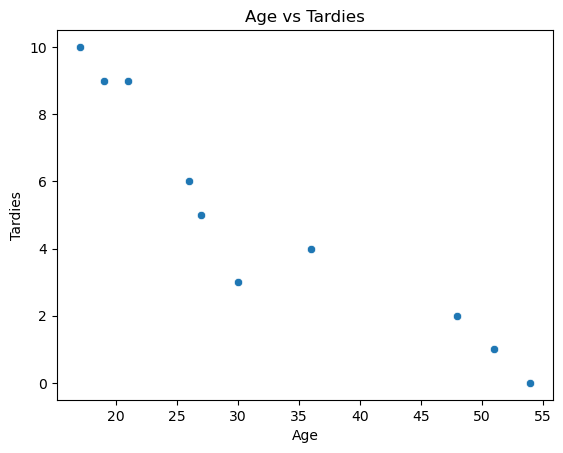

In [7]:
sns.scatterplot(
    x=age, 
    y=tardies
    )
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Age vs Tardies')
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

*your explanation here*

The number of tardies tends to decrease with the increase in age. This indicates that older students tend to be late to class less often.

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [8]:
covariance = student_data['Age'].cov(student_data['Tardies'])
correlation = student_data['Age'].corr(student_data['Tardies'])
print(f"Covariance: {covariance:.3f}")
print(f"Correlation: {correlation:.3f}")

Covariance: -45.567
Correlation: -0.939


Correlation provides the strenght and direction of a linear correlation between two variables. With a correlation of -0.939, the variables 'Age' and 'Tardies' have a strong linear anti-correlation (value close to -1).

Covariance indicates the direction of the correlation and not the strenght. With a covariance of -45.567, the variables show anti-correlation, which means that when one increases, the other decreases.

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [9]:
linear_regression = st.linregress(age, tardies)
print("Linear regression results:")
print(f"Slope: {linear_regression.slope:.3f}")
print(f"Intercept: {linear_regression.intercept:.3f}")
print(f"R-value: {linear_regression.rvalue:.3f}")
print(f"P-value {linear_regression.pvalue}")

Linear regression results:
Slope: -0.243
Intercept: 12.889
R-value: -0.939
P-value 5.566653834553354e-05


In [10]:
# your explanation here
# Linear regression model, using age as predictor variable and tardies as outcome variable.
model=[]
for x in age:
    model.append(x*linear_regression.slope + linear_regression.intercept)

For this data, a linear regression is being used, considering the correlation coefficient previously obtained. 

The outcome variable is the number of tardies, considered that it's being predicted from the variable age.

Plot your regression model on your scatter plot.

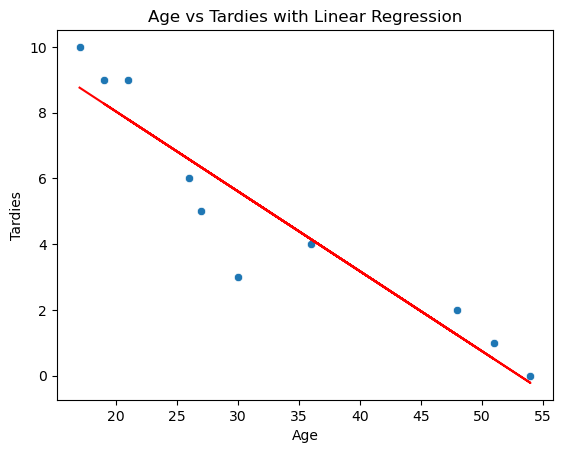

In [11]:
# Your code here.
sns.scatterplot(
    x=age, 
    y=tardies
)
plt.plot(
    age,
    model,
    color='red'
)

plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Age vs Tardies with Linear Regression')
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

*your explanation here*

This model shows that the number of tardies tends to decrease by 0.25 (linear regression slope) per year of age.

Wit a correlation coefficient of -0.939, age seems to be a good predictor of tardiness.

However, it's important to highlit that the sample size is small. For a more robust analysis, a larger sample size should be evaluated.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [12]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

In [13]:
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [14]:
vehicles.shape

(35952, 15)

In [15]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35952 entries, 0 to 35951
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Make                     35952 non-null  object 
 1   Model                    35952 non-null  object 
 2   Year                     35952 non-null  int64  
 3   Engine Displacement      35952 non-null  float64
 4   Cylinders                35952 non-null  float64
 5   Transmission             35952 non-null  object 
 6   Drivetrain               35952 non-null  object 
 7   Vehicle Class            35952 non-null  object 
 8   Fuel Type                35952 non-null  object 
 9   Fuel Barrels/Year        35952 non-null  float64
 10  City MPG                 35952 non-null  int64  
 11  Highway MPG              35952 non-null  int64  
 12  Combined MPG             35952 non-null  int64  
 13  CO2 Emission Grams/Mile  35952 non-null  float64
 14  Fuel Cost/Year        

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [16]:
variables = [
    'Year',
    'Cylinders',
    'Fuel Barrels/Year',
    'Combined MPG',
    'Fuel Cost/Year'
]

outcome = 'CO2 Emission Grams/Mile'

for x in variables:
    correlations = vehicles[x].corr(vehicles[outcome])
    print(x,":", round(correlations, 3))


Year : -0.222
Cylinders : 0.752
Fuel Barrels/Year : 0.986
Combined MPG : -0.926
Fuel Cost/Year : 0.931


The variable 'Fuel Barrels/Year" is the most important in determining CO2 emissions, considering it presents the larger correlation coefficient in module (0.986). 

The variable 'Year' provides the least amount of helpful information for determining CO2 emissions, considering it presents the smaller correlation coefficient in module (0.222). 

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [99]:
X = vehicles[['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year']].to_numpy()
print(X)
print(X.shape)


[[1984.            4.           19.38882353   17.         1950.        ]
 [1984.            6.           25.35461538   13.         2550.        ]
 [1985.            4.           20.600625     16.         2100.        ]
 ...
 [2015.            3.            9.15583333   36.         1100.        ]
 [2016.            3.            9.15583333   36.         1100.        ]
 [2016.            3.            9.41742857   35.         1150.        ]]
(35952, 5)


In [100]:
y = vehicles['CO2 Emission Grams/Mile']
print(y)
print(y.shape)

0        522.764706
1        683.615385
2        555.437500
3        683.615385
4        555.437500
            ...    
35947    244.000000
35948    243.000000
35949    244.000000
35950    246.000000
35951    255.000000
Name: CO2 Emission Grams/Mile, Length: 35952, dtype: float64
(35952,)


In [101]:
# Create the Linear Regression estimator
auto_model = LinearRegression()

# Perform the fitting
auto_model.fit(X, y)
print("Intercept:", auto_model.intercept_)
print("Coefficients:", auto_model.coef_)

Intercept: 769.8882836465696
Coefficients: [-0.32061673  1.87879976 19.05292507 -3.04039938  0.03230948]


In [103]:
from sklearn.metrics import r2_score

y_pred = auto_model.predict(X)

# Compute Score
print('R-squared:', r2_score(y, y_pred))

R-squared: 0.9808734920269122


A multiple linear regression model was used for this data, considering there are more than 1 predictor variable.

The model shows an R-squared of 0.98, indicating an excelent fit of the data.

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [106]:
# Your code here.
import statsmodels.api as sm

X = sm.add_constant(X)

est = sm.OLS(y, X) # Creates an object OLS estimator
est = est.fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     CO2 Emission Grams/Mile   R-squared:                       0.981
Model:                                 OLS   Adj. R-squared:                  0.981
Method:                      Least Squares   F-statistic:                 3.687e+05
Date:                     Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                             22:55:24   Log-Likelihood:            -1.5173e+05
No. Observations:                    35952   AIC:                         3.035e+05
Df Residuals:                        35946   BIC:                         3.035e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        769.8883     19.392     39.702      0.000     731.880     807.897
x1            -0.3206      0.010    -33.060      0.000      -0.340      -0.302
x2             1.8788      0.083     22.598      0.000       1.716       2.042
x3            19.0529      0.061    311.600      0.000      18.933      19.173
x4            -3.0404      0.042    -71.645      0.000      -3.124      -2.957
x5             0.0323      0.000     67.025      0.000       0.031       0.033
==============================================================================
Omnibus:                    71055.645   Durbin-Watson:                   0.747
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        246941260.782
Skew:                          15.902   Prob(JB):                         0.00
Kurtosis:                     407.766   Cond. No.                     6.20e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.2e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Fuel Barrels/Year stands out as the strongest predictor because it has by far the largest absolute t-value, which means it contributes the strongest unique signal once the other variables are already in the model. Combined MPG is also very important, but in the opposite direction, since better fuel economy is associated with lower CO2 emissions.

The very high R-squared (0.981) and small P-values show this model is robust in prdicting the CO2 emissions.

However, the condition number is large, which might indicate that there are strong multicolinearity.

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [140]:
X = [1, 3, 4, 6, 8, 9, 11, 14]
y = [1, 2, 4, 4, 5, 7, 8, 13]

df = pd.DataFrame({
    'X' : X,
    'Y': y
})

df

,X,Y
0,1,1
1,3,2
2,4,4
3,6,4
4,8,5
5,9,7
6,11,8
7,14,13


In [141]:
# Your code here.
X = np.array(X).reshape(-1, 1)
X.shape

(8, 1)

In [142]:
y = np.array(y)
y.shape

(8,)

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

In [131]:
# Your code here.
party_model = LinearRegression()

party_model.fit(X, y)
print("Intercept:", party_model.intercept_)
print("Coefficient:", party_model.coef_)

Intercept: -0.43939393939393945
Coefficient: [0.84848485]


In [133]:
y_pred = party_model.predict(X)

# Compute Score
print('R-squared:', r2_score(y, y_pred))

R-squared: 0.9316696375519905


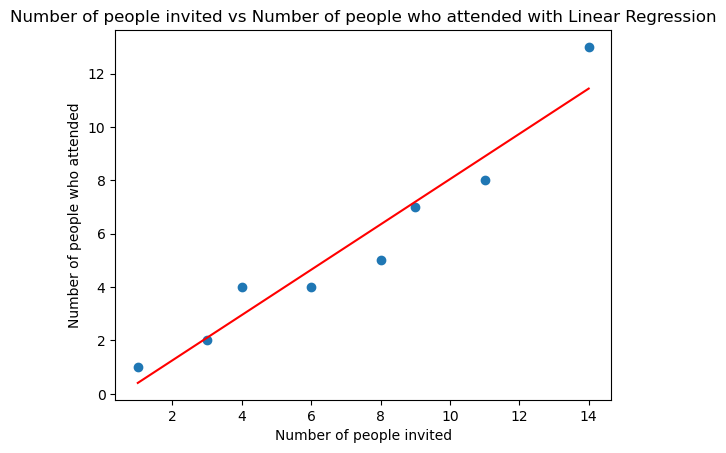

In [137]:
plt.scatter(
    X,
    y
)

plt.plot(
    X,
    y_pred,
    color='red'
)

plt.xlabel('Number of people invited')
plt.ylabel('Number of people who attended')
plt.title('Number of people invited vs Number of people who attended with Linear Regression')
plt.show()

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

*your explanation here*

The plot shows a clear positive relationship, where as the number of people invited increases, the number of people who attend the party also increases. The model shows an R-squared of 0.932, showing an excelent fit of the data.

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

In [158]:
# Comoute residuals
resid = y - y_pred
std_resid = resid / resid.std(ddof=1)

# Find the point with the largest residual
outlier_idx = int(np.argmax(np.abs(std_resid)))
df.iloc[outlier_idx]

X    14
Y    13
Name: 7, dtype: int64

This shows that the point with index 7 has the largest outlier, so it will be dropped.

In [160]:
# Removig the outlier using its index
df = df[0:7]
df

,X,Y
0,1,1
1,3,2
2,4,4
3,6,4
4,8,5
5,9,7
6,11,8


In [166]:
X_reduced = np.array(df['X']).reshape(-1, 1)
y_reduced = np.array(df['Y'])
print(X_reduced.shape)
print(y_reduced.shape)

(7, 1)
(7,)


In [167]:
party_model_reduced = LinearRegression()

party_model_reduced.fit(X_reduced, y_reduced)
print("Intercept:", party_model_reduced.intercept_)
print("Coefficient:", party_model_reduced.coef_)

Intercept: 0.32330827067669343
Coefficient: [0.68421053]


In [168]:
y_pred_reduced = party_model_reduced.predict(X_reduced)

# Compute Score
print('R-squared:', r2_score(y_reduced, y_pred_reduced))

R-squared: 0.9433811802232855


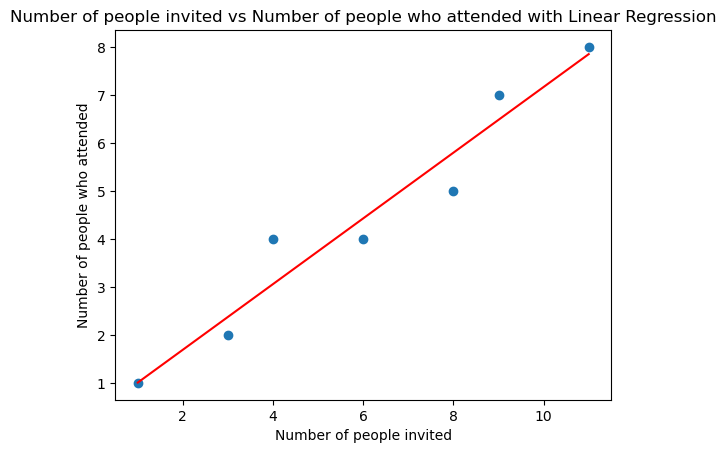

In [169]:
plt.scatter(
    X_reduced,
    y_reduced
)

plt.plot(
    X_reduced,
    y_pred_reduced,
    color='red'
)

plt.xlabel('Number of people invited')
plt.ylabel('Number of people who attended')
plt.title('Number of people invited vs Number of people who attended with Linear Regression')
plt.show()

The new R-squared is slightly higher than before (0.943 vs 0.931), which suggests the refitted line describes the remaining points a bit better.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*

The original data already showed a positive linear relationship, and that still holds after removing the outlier. With the point removed, the slope becomes smaller (0.684 vs 0.848), which means the original high-end point was pulling the regression line upward somewhat.

However, it must be emphasized that this is a very small dataset, so removing even one point can noticeably change the model.